<a href="https://colab.research.google.com/github/Rafaelsn11/smoking_driking_dataset/blob/main/C%C3%B3pia_de_Equipe_04_smoking_driking_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de IA: Análise Especializada de Tabagismo
Este notebook foca exclusivamente na classificação e análise do impacto biológico nos grupos de: **Nunca Fumou**, **Ex-Fumante** e **Fumante Atual**.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils import resample
from scipy.stats import entropy

# 1. Carregamento e Exploração Inicial
file_path = '/content/Equipe-04_smoking_driking_dataset.csv'
df = pd.read_csv(file_path)

# Visualização das primeiras linhas
print("--- Primeiras 5 linhas do Dataset ---")
display(df.head())

# Informações gerais sobre colunas e tipos de dados
print("\n--- Informações do Dataset ---")
display(df.info())

# Estatísticas descritivas básicas
print("\n--- Resumo Estatístico ---")
display(df.describe())

# Verificação do formato (linhas, colunas)
print(f'\nShape inicial do dataset: {df.shape}')

--- Primeiras 5 linhas do Dataset ---


,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N



--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  f

None


--- Resumo Estatístico ---


,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,...,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd
count,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,...,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000
mean,47.614491,162.240625,63.284050,81.233358,0.980834,0.978429,1.031495,1.030476,122.432498,76.052627,...,56.936800,113.037692,132.141751,14.229824,1.094224,0.860467,25.989308,25.755051,37.136347,1.608122
std,14.181339,9.282957,12.514241,11.850323,0.605949,0.604774,0.174650,0.171892,14.543148,9.889365,...,17.238479,35.842812,102.196985,1.584929,0.437724,0.480530,23.493386,26.308599,50.424153,0.818507
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,1.000000,1.000000,67.000000,32.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000,1.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,1.000000,1.000000,112.000000,70.000000,...,46.000000,89.000000,73.000000,13.200000,1.000000,0.700000,19.000000,15.000000,16.000000,1.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,111.000000,106.000000,14.300000,1.000000,0.800000,23.000000,20.000000,23.000000,1.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,1.000000,1.000000,131.000000,82.000000,...,66.000000,135.000000,159.000000,15.400000,1.000000,1.000000,28.000000,29.000000,39.000000,2.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,2.000000,2.000000,273.000000,185.000000,...,8110.000000,5119.000000,9490.000000,25.000000,6.000000,98.000000,9999.000000,7210.000000,999.000000,3.000000



Shape inicial do dataset: (991346, 24)


Para iniciar o projeto, realizamos o carregamento dos dados e uma exploração inicial. Esta etapa é fundamental para entendermos a dimensionalidade do dataset (quase 1 milhão de linhas) e identificarmos os tipos de variáveis presentes, como dados biométricos (peso, altura, colesterol) e hábitos (fumo e álcool), permitindo planejar as próximas etapas de limpeza.

In [48]:
#2. Limpeza de Dados (Nulos, Duplicados e Outliers)

# Remoção de duplicatas
initial_shape = df.shape
df = df.drop_duplicates()
print(f"Duplicatas removidas: {initial_shape[0] - df.shape[0]}")

# Verificação de nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())

# Tratamento de Outliers usando o método IQR (Interquartile Range) para colunas numéricas principais
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filtra mantendo apenas o que está dentro dos limites
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"\nShape após remoção de outliers: {df.shape}")

Duplicatas removidas: 26

Valores nulos por coluna:
sex                 0
age                 0
height              0
weight              0
waistline           0
sight_left          0
sight_right         0
hear_left           0
hear_right          0
SBP                 0
DBP                 0
BLDS                0
tot_chole           0
HDL_chole           0
LDL_chole           0
triglyceride        0
hemoglobin          0
urine_protein       0
serum_creatinine    0
SGOT_AST            0
SGOT_ALT            0
gamma_GTP           0
SMK_stat_type_cd    0
DRK_YN              0
dtype: int64

Shape após remoção de outliers: (577945, 24)


### Preparação de Dados para Machine Learning (Foco em Tabagismo)
Nesta etapa, vamos preparar o dataset especificamente para a classificação do status de fumo, garantindo que os dados estejam balanceados e em uma escala uniforme.

In [49]:
# --- PIPELINE EXCLUSIVO PARA ANÁLISE DE TABAGISMO ---

def process_smoking_data(df_raw):
    df = df_raw.copy().drop_duplicates()

    # Codificação de Sexo para análise estatística
    df['sex'] = LabelEncoder().fit_transform(df['sex'])

    # Engenharia de Atributos focada em riscos do fumo
    df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
    df['atherogenic_index'] = np.log10(df['triglyceride'] / df['HDL_chole'])

    # Foco total nos status de fumo
    smoking_map = {1.0: 'Nunca Fumou', 2.0: 'Ex-Fumante', 3.0: 'Fumante Atual'}
    df['smoking_class'] = df['SMK_stat_type_cd'].map(smoking_map)

    return df

df_processed = process_smoking_data(df)

# Balanceamento estrito entre os 3 grupos de fumo
min_samples = df_processed['smoking_class'].value_counts().min()
df_balanced = pd.concat([
    resample(df_processed[df_processed['smoking_class'] == cls],
             replace=False, n_samples=min_samples, random_state=42)
    for cls in ['Nunca Fumou', 'Ex-Fumante', 'Fumante Atual']
]).reset_index(drop=True)

# Padronização para análise de impacto comparativo
numeric_cols = df_balanced.select_dtypes(include=[np.number]).columns.drop('SMK_stat_type_cd')
scaler = StandardScaler()
df_final = df_balanced.copy()
df_final[numeric_cols] = scaler.fit_transform(df_balanced[numeric_cols])

print(f"Dataset pronto! Foco exclusivo em 3 classes de fumo. Total: {len(df_final)} registros.")

Dataset pronto! Foco exclusivo em 3 classes de fumo. Total: 257049 registros.


In [50]:
# Lista de colunas para remover
cols_to_drop = [
    'SMK_stat_type_cd', 'sight_left', 'sight_right',
    'hear_left', 'hear_right', 'height', 'weight'
]

# Criando o DataFrame de treino (X) e o alvo (y)
df_ml_final = df_final.drop(columns=cols_to_drop)

# Codificando a última coluna categórica restante (DRK_YN)
le = LabelEncoder()
df_ml_final['DRK_YN'] = le.fit_transform(df_ml_final['DRK_YN'])

print(f"Colunas removidas: {cols_to_drop}")
print(f"Colunas restantes para o modelo ({len(df_ml_final.columns)}):")
print(df_ml_final.columns.tolist())

display(df_ml_final.head())

Colunas removidas: ['SMK_stat_type_cd', 'sight_left', 'sight_right', 'hear_left', 'hear_right', 'height', 'weight']
Colunas restantes para o modelo (20):
['sex', 'age', 'waistline', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP', 'DRK_YN', 'BMI', 'atherogenic_index', 'smoking_class']


,sex,age,waistline,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,DRK_YN,BMI,atherogenic_index,smoking_class
0,-1.454314,0.297708,1.220724,0.771090,1.298166,0.626679,1.455865,1.346697,1.013715,0.026920,-0.648670,0.0,-2.045354,-1.314196,-1.043746,-0.945775,1,1.874868,-0.295623,Nunca Fumou
1,-1.454314,0.660819,-0.751474,-0.032018,-0.581157,-0.737280,-0.126802,-0.557902,-0.089654,0.567788,0.431435,0.0,-0.426969,-0.377224,0.291833,-0.392151,0,0.114481,0.749200,Nunca Fumou
2,-1.454314,-1.517847,-2.082114,-1.477611,-0.111326,0.808541,-0.126802,1.651432,-0.479079,-1.112766,-0.720677,0.0,0.112493,-0.002435,-1.043746,-1.222587,0,-1.062110,-1.612530,Nunca Fumou
3,-1.454314,0.297708,0.650450,1.975751,0.828335,0.172026,0.709324,0.965777,0.397126,-0.031030,-0.720677,0.0,0.112493,1.496720,2.428758,-0.299880,0,1.285597,-0.225231,Nunca Fumou
4,0.687610,-0.065403,0.697973,1.092333,1.533082,0.444818,1.575312,1.194329,1.208428,-0.011713,0.359428,0.0,0.112493,-0.377224,-0.242399,0.253744,0,0.749079,-0.280198,Nunca Fumou


## 5. Visualização de Dados
Nesta etapa final, transformamos as métricas calculadas em gráficos para facilitar a interpretação dos padrões de saúde e comportamento.

/tmp/ipykernel_2130/3032986670.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_balanced, x='smoking_class', palette='magma', ax=axes[0])
/tmp/ipykernel_2130/3032986670.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_balanced, x='smoking_class', y='hemoglobin', palette='magma', ax=axes[1])


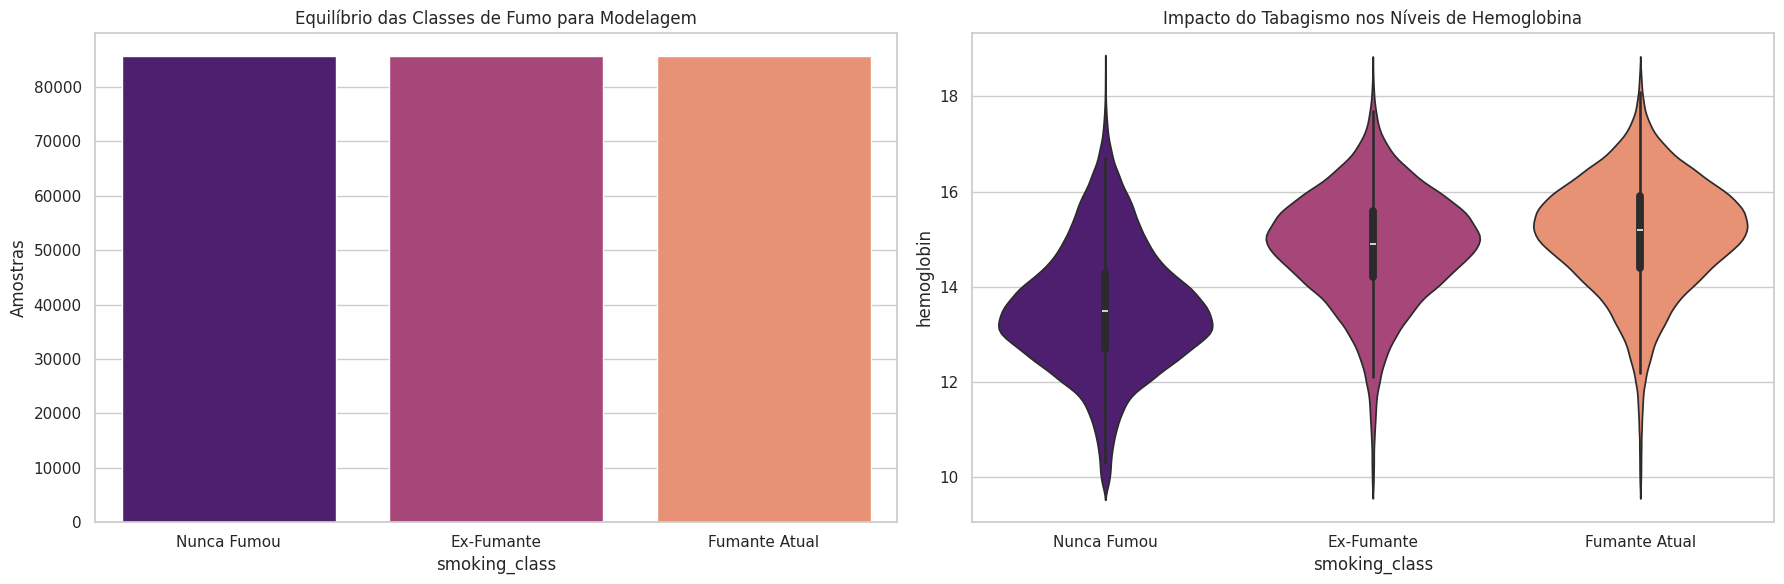

In [51]:
# Visualização Focada no Perfil do Fumante
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribuição de Classes (Verificação de Balanceamento)
sns.countplot(data=df_balanced, x='smoking_class', palette='magma', ax=axes[0])
axes[0].set_title('Equilíbrio das Classes de Fumo para Modelagem')
axes[0].set_ylabel('Amostras')

# 2. Impacto do Fumo na Hemoglobina (Capacidade de oxigenação)
sns.violinplot(data=df_balanced, x='smoking_class', y='hemoglobin', palette='magma', ax=axes[1])
axes[1].set_title('Impacto do Tabagismo nos Níveis de Hemoglobina')

plt.tight_layout()
plt.show()

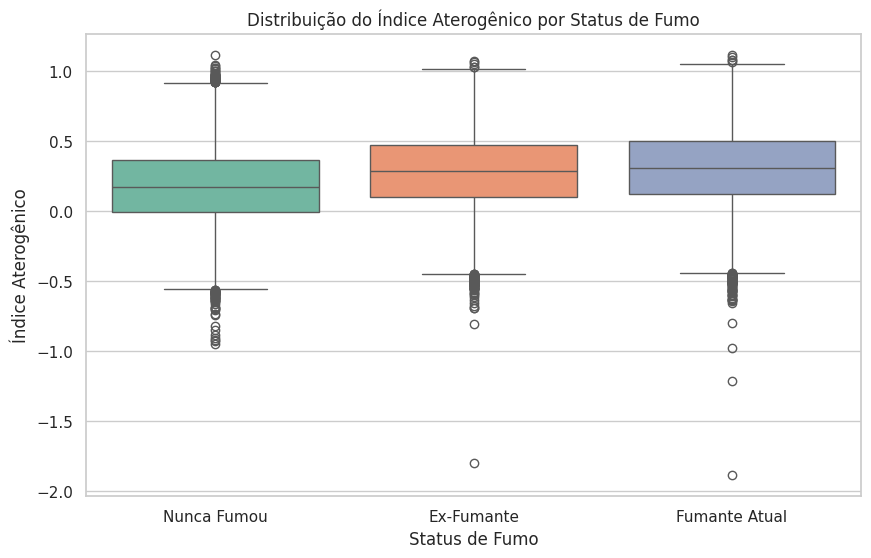

In [52]:
# BOXPLOT: Índice Aterogênico por Status de Fumo

# O boxplot exibe:
# - Mediana (linha central)
# - Quartis (caixa)
# - Outliers (pontos fora da curva)

plt.figure(figsize=(10,6))

# Mapear SMK_stat_type_cd para rótulos descritivos
df_balanced_plot = df_balanced.copy()
df_balanced_plot['SMK_stat_type_cd_label'] = df_balanced_plot['SMK_stat_type_cd'].map({1.0: 'Nunca Fumou', 2.0: 'Ex-Fumante', 3.0: 'Fumante Atual'})

sns.boxplot(
    data=df_balanced_plot,
    x='SMK_stat_type_cd_label',  # Status de fumo (1, 2, 3)
    y='atherogenic_index',              # Índice calculado anteriormente
    palette='Set2',
    hue='SMK_stat_type_cd_label', # Fix: add hue for clarity and to remove FutureWaring
    legend=False # Fix: remove legend as hue is the x-axis
)

plt.title('Distribuição do Índice Aterogênico por Status de Fumo')
plt.xlabel('Status de Fumo')
plt.ylabel('Índice Aterogênico')

plt.show()

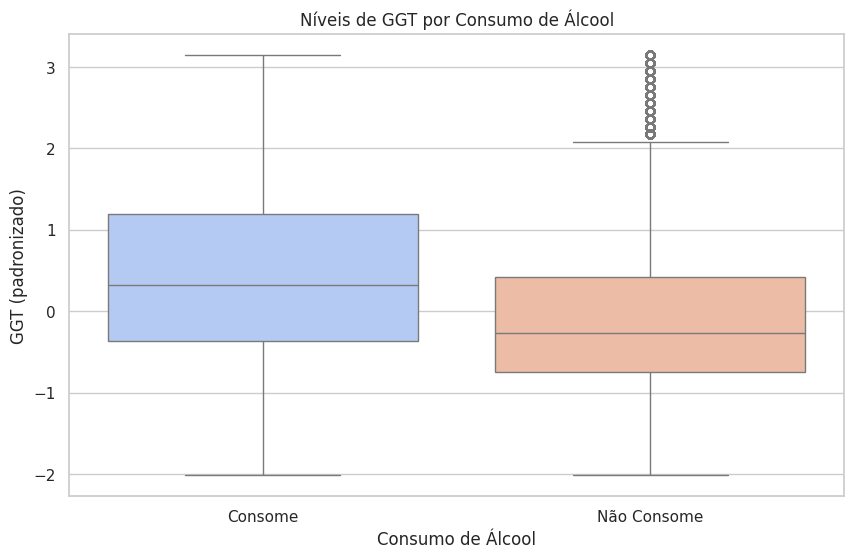

In [ ]:
# BOXPLOT: Níveis de GGT por Consumo de Álcool

# Aqui analisamos a relação entre consumo de álcool (DRK_YN)
# e os níveis da enzima hepática GGT (gamma_GTP).

plt.figure(figsize=(10,6))

# Criando uma cópia para o gráfico e mapeando os rótulos
df_balanced_plot = df_balanced.copy()
# Verificando se os valores são numéricos ou strings para o mapeamento correto
df_balanced_plot['DRK_YN_label'] = df_balanced_plot['DRK_YN'].apply(lambda x: 'Consome' if x > 0 else 'Não Consome')

# Correção do erro: Definimos explicitamente o hue igual ao x para evitar o bug do 'boxprops'
sns.boxplot(
    data=df_balanced_plot,
    x='DRK_YN_label',
    y='gamma_GTP',
    hue='DRK_YN_label',
    palette='coolwarm',
    legend=False
)

plt.title('Níveis de GGT por Consumo de Álcool')
plt.xlabel('Consumo de Álcool')
plt.ylabel('GGT (padronizado)')

plt.show()

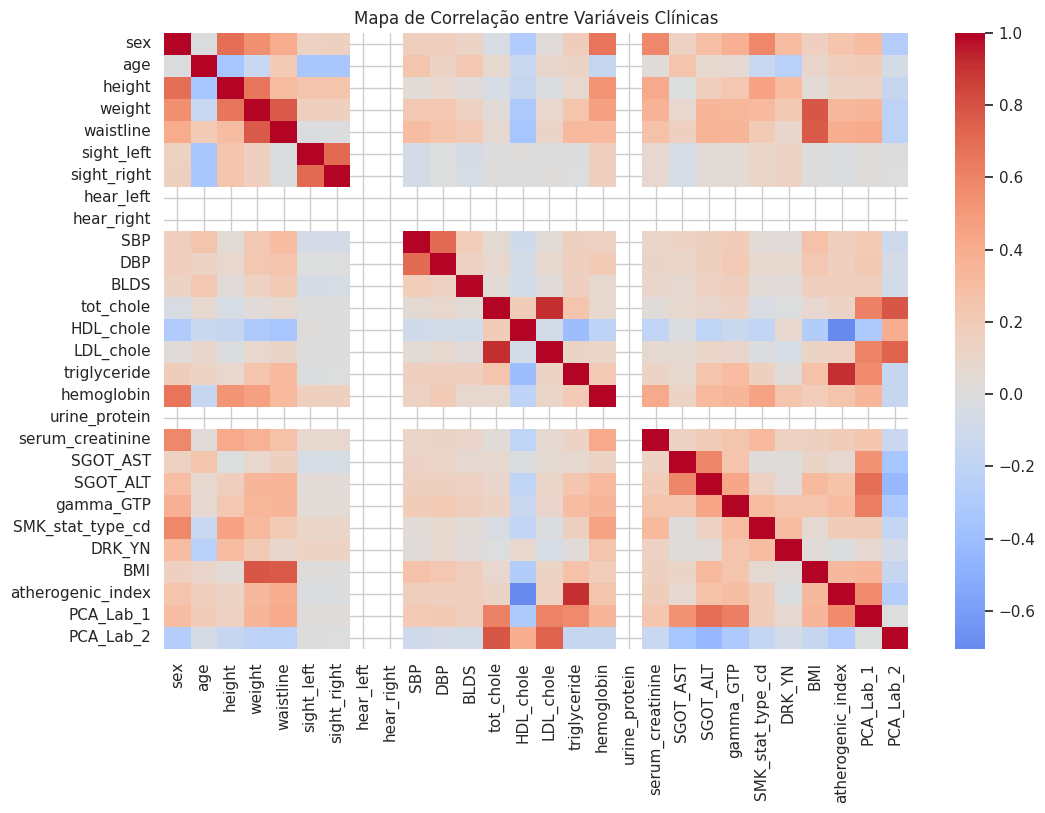

In [ ]:

# HEATMAP: Correlação entre Variáveis Numéricas

# Este mapa de calor mostra a correlação entre todas as variáveis numéricas.
# Correlação varia de:
# -1 → relação negativa forte
#  0 → sem relação
# +1 → relação positiva forte

# Seleciona apenas colunas numéricas
corr = df_balanced.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0  # centraliza a escala no zero
)

plt.title('Mapa de Correlação entre Variáveis Clínicas')

plt.show()

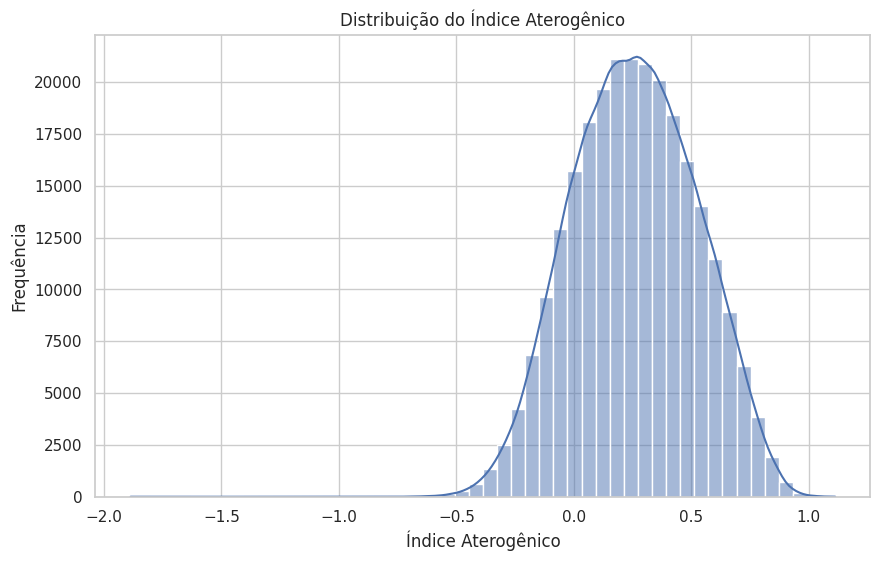

In [ ]:
# HISTOGRAMA: Distribuição do Índice Aterogênico

# Este gráfico mostra como os valores do índice aterogênico
# estão distribuídos na população.
# A curva KDE (linha suave) ajuda a visualizar a densidade dos dados.

plt.figure(figsize=(10,6))

sns.histplot(
    df_balanced['atherogenic_index'],
    bins=50,     # número de divisões do histograma
    kde=True     # adiciona curva de densidade
)

plt.title('Distribuição do Índice Aterogênico')
plt.xlabel('Índice Aterogênico')
plt.ylabel('Frequência')

plt.show()

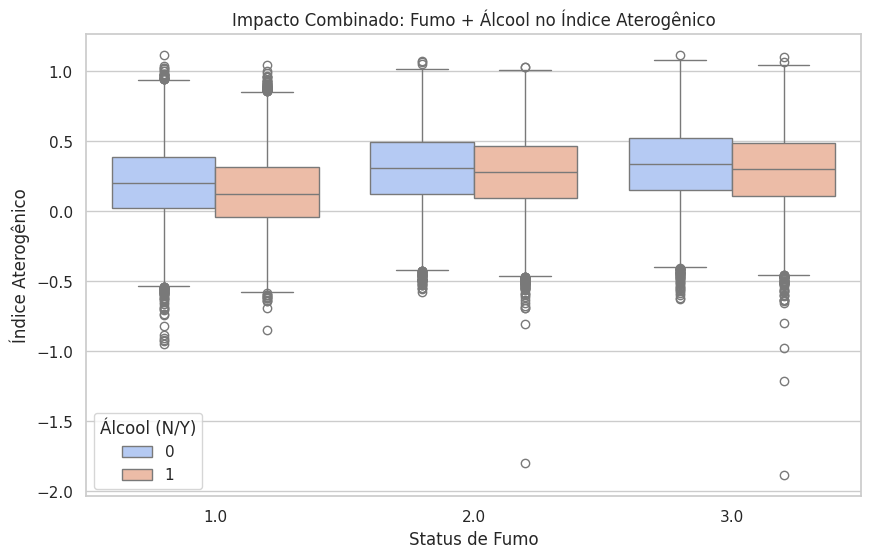

In [ ]:
# BOXPLOT: Impacto combinado de Fumo e Álcool


# Este gráfico analisa o efeito combinado de dois fatores:
# - Status de fumo
# - Consumo de álcool
#
# A cor (hue) representa o consumo de álcool,
# permitindo comparar dentro de cada grupo de fumantes.

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_balanced,
    x=df_balanced['SMK_stat_type_cd'],  # Fumo
    y='atherogenic_index',              # Índice de risco
    hue='DRK_YN',                       # Álcool
    palette='coolwarm'
)

plt.title('Impacto Combinado: Fumo + Álcool no Índice Aterogênico')
plt.xlabel('Status de Fumo')
plt.ylabel('Índice Aterogênico')

plt.legend(title='Álcool (N/Y)')

plt.show()

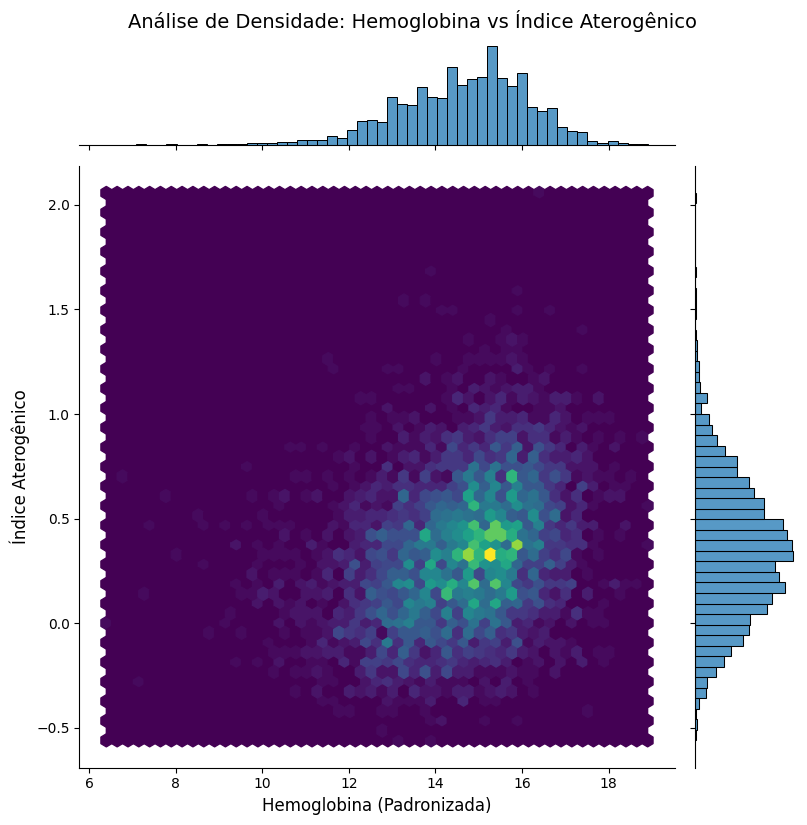

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# GRÁFICO DE DISPERSÃO E DENSIDADE (JointPlot)
# Usando o df_balanced que já foi processado nas células anteriores.

# Verificação de segurança: garantir que os dados estão acessíveis
try:
    # Selecionando uma amostra para otimizar a visualização
    sample_df = df_balanced.sample(n=min(5000, len(df_balanced)), random_state=42)

    # Criando o gráfico
    # O tipo 'hex' é excelente para substituir o pairplot pois lida melhor com densidade de pontos
    g = sns.jointplot(
        data=sample_df,
        x='hemoglobin',
        y='atherogenic_index',
        kind='hex',
        cmap='viridis',
        height=8
    )

    # Ajustes de título e labels
    g.fig.suptitle('Análise de Densidade: Hemoglobina vs Índice Aterogênico', y=1.02, fontsize=14)
    g.set_axis_labels('Hemoglobina (Padronizada)', 'Índice Aterogênico', fontsize=12)

    plt.show()
except NameError:
    print("Erro: Certifique-se de executar as células de processamento de dados acima antes de gerar este gráfico.")